# Q8 Decision Tree Sub-Model
**Question:** *How many different languages might you overhear during a stroll through the city?*

**Note:** The main
modeling challenge here is data cleaning (missing values, extreme outliers) rather
than feature extraction. Splits/thresholds are tuned with sklearn during exploration and the final fitted tree is implemented in numpy at the end for pred.py.

In [1]:
import matplotlib.pyplot as plt # For plotting
import numpy as np              # Linear algebra library
import pandas as pd             # For manipulating tabular data
import re

Step 1: Create the master dataframe

In [2]:
# Load the raw master dataset (same file used for every sub-model)
df_master = pd.read_csv('cleaned_dataset.csv')

# Drop any rows missing labels and reset the index to establish absolute row positions
df_master = df_master.dropna(subset=['Label']).reset_index(drop=True)

df_master.describe()

,id,Q1,Q2,Q3,Q4,Q8
count,1462.000000,1462.000000,1461.000000,1461.000000,1462.000000,1461.000000
mean,460237.614911,4.321477,3.521561,3.707734,3.391929,4.796030
std,112789.365108,0.884464,1.192031,1.142037,1.297189,22.142305
min,5978.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,407927.000000,4.000000,3.000000,3.000000,2.000000,2.000000
50%,503416.000000,5.000000,4.000000,4.000000,3.000000,3.000000
75%,522169.000000,5.000000,5.000000,5.000000,5.000000,5.000000
max,727099.000000,5.000000,5.000000,5.000000,5.000000,800.000000


Step 2: Data split (identical code to all sub-models)

In [3]:
# Capture a master index array representing every single row position, and randomize rows
df_master = df_master.sample(frac=1, random_state=42).reset_index(drop=True)

master_indices = np.arange(len(df_master))
labels = df_master['Label']

# Print the first 20 rows of the shuffled dataset to verify randomization
print("=== SHUFFLE VERIFICATION REPORT ===")
print(df_master[['Label']].head(20))

print("\n=== CLASS DISTRIBUTION IN TOP 20 ROWS ===")
print(df_master['Label'].head(20).value_counts())

=== SHUFFLE VERIFICATION REPORT ===
             Label
0    New York City
1            Paris
2   Rio de Janeiro
3   Rio de Janeiro
4    New York City
5   Rio de Janeiro
6            Dubai
7            Paris
8   Rio de Janeiro
9    New York City
10  Rio de Janeiro
11           Paris
12   New York City
13  Rio de Janeiro
14           Paris
15           Paris
16           Dubai
17           Paris
18           Paris
19           Dubai

=== CLASS DISTRIBUTION IN TOP 20 ROWS ===
Label
Paris             7
Rio de Janeiro    6
New York City     4
Dubai             3
Name: count, dtype: int64


In [4]:
from sklearn.model_selection import train_test_split

# Step A: Isolate 20% of indices for the Final Evaluation/Test Set
train_meta_idx, global_test_idx, y_train_meta, y_test = train_test_split(
    master_indices, labels, test_size=0.20, stratify=labels, random_state=42
)

# Step B: Split the remaining 80% into 70% Training and 10% Validation indices
global_train_idx, global_val_idx, y_train, y_val = train_test_split(
    train_meta_idx, y_train_meta, test_size=0.125, stratify=y_train_meta, random_state=42
)

# Step C: Split the 70% Training into 80% sub-model training + 20% sub-model validation
labels_train_pool = labels[global_train_idx]
train_idx, val_idx, y_sub_train, y_sub_val = train_test_split(
    global_train_idx, labels_train_pool, test_size=0.20, stratify=labels_train_pool, random_state=42
)

print("=== GLOBAL INDEX SPLIT REGISTRY (identical to Q10/Q5) ===")
print(f"Training Row Indices (70%):  {len(global_train_idx)} rows")
print(f"Validation Row Indices (10%): {len(global_val_idx)} rows")
print(f"Evaluation Row Indices (20%): {len(global_test_idx)} rows")
print(f"Sub-model Training Row Indices (80% of 70%):  {len(train_idx)} rows")
print(f"Sub-model Validation Row Indices (20% of 70%): {len(val_idx)} rows")

=== GLOBAL INDEX SPLIT REGISTRY (identical to Q10/Q5) ===
Training Row Indices (70%):  1022 rows
Validation Row Indices (10%): 147 rows
Evaluation Row Indices (20%): 293 rows
Sub-model Training Row Indices (80% of 70%):  817 rows
Sub-model Validation Row Indices (20% of 70%): 205 rows


Step 3: Cleaning and preparing Q8 for modeling

Q8 is a raw integer response, but it's noisy: a handful of respondents gave implausible answers (a person cannot realistically "overhear" 200 or 800 different languages on one walk). We inspect the raw distribution first, then decide how to handle both issues, fitting any statistics (like the outlier cap) using ONLY the training-pool rows (`global_train_idx`) to avoid
leaking information about the validation/test distribution into our preprocessing.

In [5]:
# Raw distribution, before any cleaning
print("--- Raw Q8 summary (entire dataset) ---")
print(df_master['Q8'].describe())

print("\nMissing values in Q8:", df_master['Q8'].isna().sum())

print("\n--- Largest 15 raw Q8 values ---")
print(sorted(df_master['Q8'].dropna().unique())[-15:])

print("\n--- Per-city raw Q8 summary ---")
print(df_master.groupby('Label')['Q8'].describe()[['count', 'mean', 'std', 'min', '50%', 'max']])

--- Raw Q8 summary (entire dataset) ---
count    1461.000000
mean        4.796030
std        22.142305
min         1.000000
25%         2.000000
50%         3.000000
75%         5.000000
max       800.000000
Name: Q8, dtype: float64

Missing values in Q8: 1

--- Largest 15 raw Q8 values ---
[np.float64(12.0), np.float64(13.0), np.float64(15.0), np.float64(20.0), np.float64(21.0), np.float64(23.0), np.float64(24.0), np.float64(25.0), np.float64(30.0), np.float64(40.0), np.float64(50.0), np.float64(87.0), np.float64(100.0), np.float64(200.0), np.float64(800.0)]

--- Per-city raw Q8 summary ---
                count      mean        std  min  50%    max
Label                                                      
Dubai           367.0  4.566757   4.087872  1.0  4.0   50.0
New York City   365.0  7.956164  43.349820  1.0  4.0  800.0
Paris           364.0  3.626374   7.148790  1.0  3.0  100.0
Rio de Janeiro  365.0  3.032877   2.233367  1.0  3.0   30.0


In [6]:
# --- 1. Impute the single missing Q8 value ---
# Use the median of the sub-model TRAINING rows only, to avoid leaking
# validation/test information into the imputed value.
train_median_q8 = df_master.loc[train_idx, 'Q8'].median()
df_master['Q8'] = df_master['Q8'].fillna(train_median_q8)
print(f"Imputed missing Q8 value(s) with training median: {train_median_q8}")

# --- 2. Decide an outlier cap using only the training pool ---
# We use the 97th percentile of the TRAINING rows as the cap threshold, rather than
# a round number, so the choice is empirically grounded in the observed data instead
# of an arbitrary guess.
cap_value = np.percentile(df_master.loc[train_idx, 'Q8'], 97)
print(f"Outlier cap (97th percentile of training Q8): {cap_value}")

# Apply the SAME cap to every row (train/val/test) -- this is just a fixed
# transformation, not something "fit" on val/test labels, so it's safe.
df_master['Q8_capped'] = df_master['Q8'].clip(upper=cap_value)

# --- 3. One extra engineered feature: "round-number" reporting behavior ---
# People often round to 5/10/20/50/100 when guessing rather than counting exactly.
# We test below whether this rounding behavior itself differs by city.
df_master['Q8_round5'] = (df_master['Q8'] % 5 == 0).astype(int)

feature_names = ['Q8_capped', 'Q8_round5']
print(f"\nFinal Q8 feature set: {feature_names}")

Imputed missing Q8 value(s) with training median: 3.0
Outlier cap (97th percentile of training Q8): 10.0

Final Q8 feature set: ['Q8_capped', 'Q8_round5']


Note: Because a decision tree's splits only depend on the rank order of a feature's values, capping is really the only cleaning step that changes what the tree can learn from Q8 alone. A log-transform would not change anything, since it's a monotonic transform and preserves rank order. That's why we capped instead of log-transforming.

Step 4: Q8 data exploration

In [7]:
train_analysis_df = df_master.loc[global_train_idx]
print(train_analysis_df['Label'].value_counts())

Label
New York City     256
Dubai             256
Paris             255
Rio de Janeiro    255
Name: count, dtype: int64


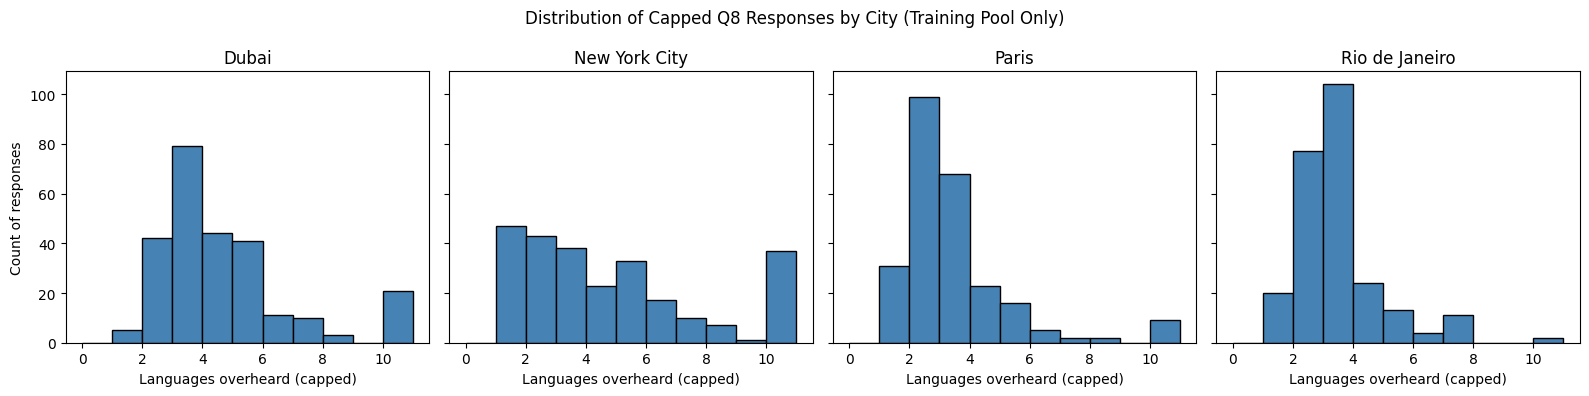

In [8]:
cities = train_analysis_df['Label'].unique()

fig, axes = plt.subplots(1, len(cities), figsize=(16, 4), sharey=True)
for ax, city in zip(axes, sorted(cities)):
    subset = train_analysis_df.loc[train_analysis_df['Label'] == city, 'Q8_capped']
    ax.hist(subset, bins=range(0, int(cap_value) + 2), color='steelblue', edgecolor='black')
    ax.set_title(city)
    ax.set_xlabel('Languages overheard (capped)')
axes[0].set_ylabel('Count of responses')
plt.suptitle('Distribution of Capped Q8 Responses by City (Training Pool Only)')
plt.tight_layout()
plt.show()

<Figure size 800x500 with 0 Axes>

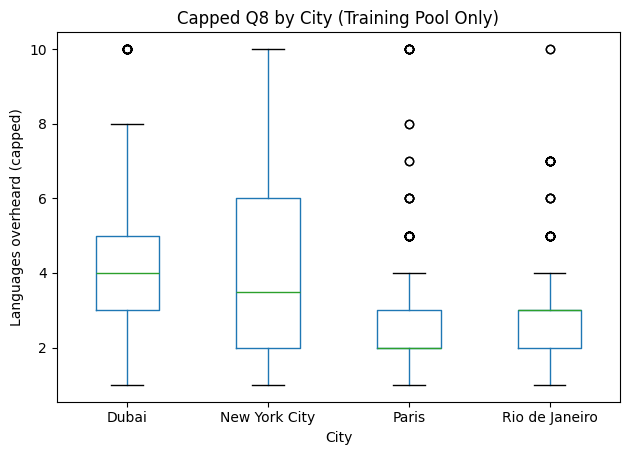

In [9]:
plt.figure(figsize=(8, 5))
train_analysis_df.boxplot(column='Q8_capped', by='Label', grid=False)
plt.title('Capped Q8 by City (Training Pool Only)')
plt.suptitle('')
plt.ylabel('Languages overheard (capped)')
plt.xlabel('City')
plt.tight_layout()
plt.show()

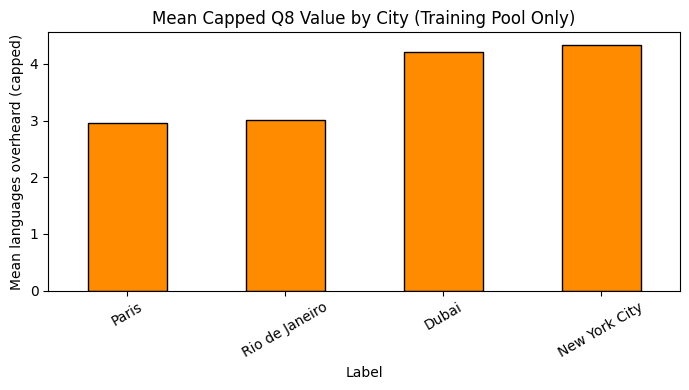

--- P(Q8 is a multiple of 5 | city) ---
Q8_round5              0         1
Label                             
Dubai           0.761719  0.238281
New York City   0.734375  0.265625
Paris           0.905882  0.094118
Rio de Janeiro  0.949020  0.050980


In [10]:
# Mean capped value per city
mean_by_city = train_analysis_df.groupby('Label')['Q8_capped'].mean().sort_values()
mean_by_city.plot(kind='bar', figsize=(7, 4), color='darkorange', edgecolor='black')
plt.title('Mean Capped Q8 Value by City (Training Pool Only)')
plt.ylabel('Mean languages overheard (capped)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# Does "rounding behavior" differ by city?
print("--- P(Q8 is a multiple of 5 | city) ---")
print(pd.crosstab(train_analysis_df['Label'], train_analysis_df['Q8_round5'], normalize='index'))

Step 5: Data splitting for Q8

In [11]:
X = df_master[feature_names].to_numpy()
t = df_master['Label'].to_numpy()

X_train, t_train = X[train_idx], t[train_idx]
X_val,   t_val   = X[val_idx],   t[val_idx]

print(X_train.shape, X_val.shape)

(817, 2) (205, 2)


Step 6: Fit a DecisionTreeClassifier

Use entropy as the split criterion, fit on the sub-model training split, and report
training/validation accuracy via .score().

In [12]:
from sklearn.tree import DecisionTreeClassifier

tree = DecisionTreeClassifier(criterion='entropy', max_depth=3)
tree.fit(X_train, t_train)

print('Training Accuracy:', tree.score(X_train, t_train))
print('Validation Accuracy:', tree.score(X_val, t_val))

Training Accuracy: 0.390452876376989
Validation Accuracy: 0.3951219512195122


Visualize the tree

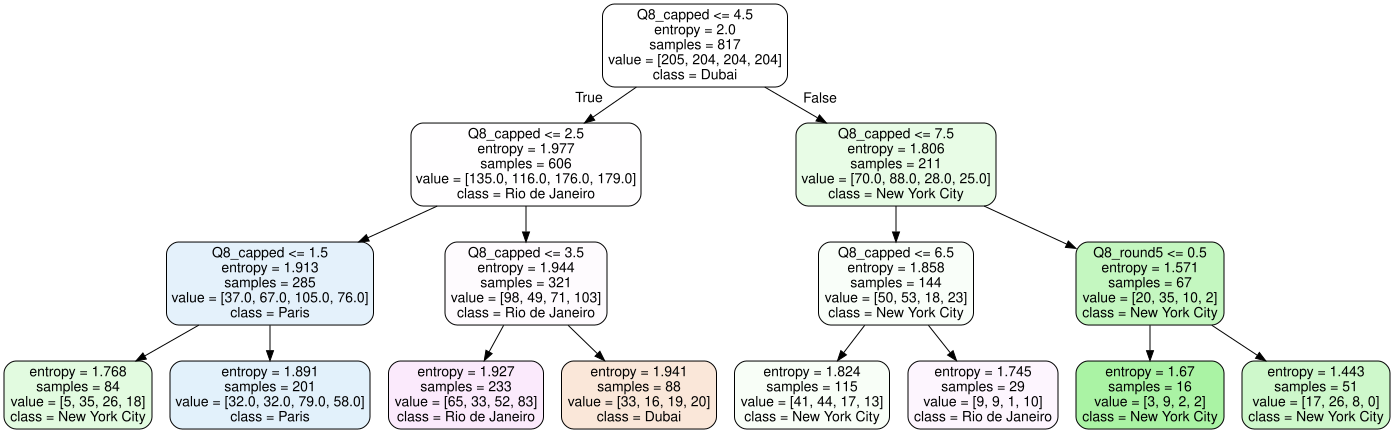

In [13]:
from sklearn import tree as treeViz
import graphviz
from IPython.display import display

def visualize_tree(model, max_depth=5):
    dot_data = treeViz.export_graphviz(
        model,
        feature_names=feature_names,
        max_depth=max_depth,
        class_names=model.classes_,
        filled=True,
        rounded=True,
    )
    return display(graphviz.Source(dot_data))

visualize_tree(tree)

In [17]:
example_idx = 14
print(dict(zip(feature_names, X_train[example_idx])))
print('True label:', t_train[example_idx])
print('Predicted label:', tree.predict(X_train[example_idx:example_idx+1])[0])

{'Q8_capped': np.float64(3.0), 'Q8_round5': np.float64(0.0)}
True label: Paris
Predicted label: Rio de Janeiro


Note: Tried multiple different example indexes but none result in the correct prediction.

Step 7: Hyperparameter tuning via grid search

In [18]:
def build_all_models(max_depths, min_samples_splits, criterion,
                      X_train=X_train, t_train=t_train, X_valid=X_val, t_valid=t_val):
    """
    Builds one DecisionTreeClassifier per (max_depth, min_samples_split) combination and
    records training + validation accuracy for each, for a fixed split criterion.
    """
    out = {}
    for d in max_depths:
        for s in min_samples_splits:
            out[(d, s)] = {}
            tree = DecisionTreeClassifier(max_depth=d, min_samples_split=s, criterion=criterion)
            tree.fit(X_train, t_train)
            out[(d, s)]['val'] = tree.score(X_valid, t_valid)
            out[(d, s)]['train'] = tree.score(X_train, t_train)
    return out

In [20]:
criterions = ['entropy', 'gini']
# NOTE: with only 2 features (one of which is binary), depth beyond ~4-6 is very
# likely to just be memorizing training noise rather than learning real structure.
# This is an overfitting risk given how few features Q8 alone provides.
max_depths = [1, 2, 3, 4, 5, 6, 8, 10, 15, 20, None]
min_samples_splits = [2, 4, 8, 16, 32, 64, 128]

grid_results = {}
for criterion in criterions:
    print(f"\nUsing criterion {criterion}")
    res = build_all_models(max_depths, min_samples_splits, criterion)
    grid_results[criterion] = res

    best_val_score, best_params = -1, None
    for d, s in res:
        if res[(d, s)]['val'] > best_val_score:
            best_val_score, best_params = res[(d, s)]['val'], (d, s)

    print(f"Best parameters: max_depth={best_params[0]}, min_samples_split={best_params[1]}")
    print(f"Training accuracy: {res[best_params]['train']:.4f}")
    print(f"Validation accuracy: {res[best_params]['val']:.4f}")


Using criterion entropy
Best parameters: max_depth=4, min_samples_split=32
Training accuracy: 0.3941
Validation accuracy: 0.4195

Using criterion gini
Best parameters: max_depth=4, min_samples_split=64
Training accuracy: 0.3941
Validation accuracy: 0.4195


In [22]:
FINAL_CRITERION = 'entropy'         # <- set from grid search output above
FINAL_MAX_DEPTH = 4                 # <- set from grid search output above
FINAL_MIN_SAMPLES_SPLIT = 32        # <- set from grid search output above

Step 8: Report training/validation accuracies for the final Q8 model

In [23]:
X_train = df_master.loc[train_idx, feature_names].to_numpy()
t_train = df_master.loc[train_idx, 'Label'].to_numpy()

final_tree = DecisionTreeClassifier(
    criterion=FINAL_CRITERION, max_depth=FINAL_MAX_DEPTH, min_samples_split=FINAL_MIN_SAMPLES_SPLIT
)
final_tree.fit(X_train, t_train)

train_acc = final_tree.score(X_train, t_train) * 100
val_acc   = final_tree.score(X_val, t_val) * 100

print("==================================================")
print(" Q8 DECISION TREE ACCURACY REPORT ")
print("==================================================")
print(f"Hyperparameters: criterion={FINAL_CRITERION} | max_depth={FINAL_MAX_DEPTH} | "
      f"min_samples_split={FINAL_MIN_SAMPLES_SPLIT}\n")
print(f"Training Accuracy (70% Pool):      {train_acc:.2f}%")
print(f"Validation Accuracy (Set B - 10%):  {val_acc:.2f}%")
print("==================================================")

 Q8 DECISION TREE ACCURACY REPORT 
Hyperparameters: criterion=entropy | max_depth=4 | min_samples_split=32

Training Accuracy (70% Pool):      39.41%
Validation Accuracy (Set B - 10%):  41.95%


Our optimized decision tree sub-model for Q8 achieved a final validation accuracy of 39.41%. This is a very weak validation accuracy.

In [24]:
t_ = final_tree.tree_
classes_ = final_tree.classes_

print("feature indices per node:", t_.feature[:10], "...")
print("thresholds per node:", t_.threshold[:10], "...")
print("classes:", classes_)

feature indices per node: [ 0  0  0 -2 -2  0 -2 -2  0  0] ...
thresholds per node: [ 4.5  2.5  1.5 -2.  -2.   3.5 -2.  -2.   7.5  6.5] ...
classes: ['Dubai' 'New York City' 'Paris' 'Rio de Janeiro']


In [25]:
def sklearn_free_predict(X, feature=t_.feature, threshold=t_.threshold,
                          children_left=t_.children_left, children_right=t_.children_right,
                          value=t_.value, classes=classes_):
    """
    Pure numpy/pandas re-implementation of sklearn's DecisionTreeClassifier.predict,
    using only the fitted tree's raw arrays. Safe to copy into pred.py.
    """
    preds = []
    for x in X:
        node = 0
        while children_left[node] != children_right[node]:  # not a leaf
            if x[feature[node]] <= threshold[node]:
                node = children_left[node]
            else:
                node = children_right[node]
        preds.append(classes[np.argmax(value[node])])
    return np.array(preds)

# Sanity check: this must match final_tree.predict(...) exactly
# sklearn_preds = final_tree.predict(X_val)
# manual_preds = sklearn_free_predict(X_val)
# print("Predictions match exactly:", np.array_equal(sklearn_preds, manual_preds))

Notes for pred.py:

1. Save `t_.feature`, `t_.threshold`, `t_.children_left`, `t_.children_right`, `t_.value`,
   and `classes_` to a small `.npz` file (np.savez) -- tiny for a shallow tree.
2. Also save `cap_value` and `train_median_q8` (both plain scalars) -- pred.py needs
   them to reproduce the exact same cleaning: impute Q8 with `train_median_q8`, then
   clip at `cap_value`, then compute `Q8_round5` the same way, before calling
   `sklearn_free_predict`. Recomputing these from the test CSV instead would leak
   test-set statistics into preprocessing and violate the fixed-pipeline assumption.
3. Copy `sklearn_free_predict` into `pred.py` unchanged; it only uses `numpy`.

Why only 2 features from Q8: a decision tree finds its own thresholds on a continuous feature, so there's no benefit to hand-binning Q8_capped into buckets as the tree does that automatically as part of training.
Why cap instead of drop: dropping the ~18 outlier rows would shrink an already-small per-city sample; capping keeps the row while preventing one implausible "800" from creating a useless one-point leaf.
Expected performance: with only 2 weak features, this sub-model weak since it's a much noisier/weaker, espicially in comparison to other submodels.